In [1]:
# Cell 1: Setup and Imports
import sys
import numpy as np
from skimage import io, color

# Add source directory to the path
sys.path.append('./src')

from module import Module, Linear, Conv2d, MaxPool2d, Flatten, ReLU, Sigmoid, Dropout, CrossEntropyLoss, SGD
from functions import F

In [2]:
# Cell 2: Define the MNIST CNN Architecture
class MNIST_CNN(Module):
    def __init__(self):
        super().__init__()
        # 28x28x1 Input -> Conv Layer (8 filters)
        self.conv1 = Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.relu1 = ReLU()
        self.pool1 = MaxPool2d(kernel_size=2, stride=2)
        
        # Flatten: 8 channels * 14 * 14
        self.flatten = Flatten()
        
        # Fully Connected Layer: 1568 inputs -> 10 output classes
        self.fc1 = Linear(in_features=(8 * 14 * 14), out_features=10)

    def forward(self, x):
        # Pass data through the layers
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return F.Softmax(x)

In [3]:
from sklearn.datasets import fetch_openml

print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Use 5,00 for training and 1,00 for testing
train_data = mnist.data[:500]
test_data = mnist.data[500:600]

train_labels_raw = mnist.target[:500].astype(int)
test_labels_raw = mnist.target[500:600].astype(int)

# Normalize and reshape
train_images = train_data.reshape(-1, 1, 28, 28) / 255.0
test_images = test_data.reshape(-1, 1, 28, 28) / 255.0

# Convert labels to One-Hot
train_labels = np.eye(10)[train_labels_raw]
test_labels = np.eye(10)[test_labels_raw]

print(f"New Training set size: {train_images.shape[0]}")
print(f"New Test set size: {test_images.shape[0]}")

Loading MNIST data...
New Training set size: 500
New Test set size: 100


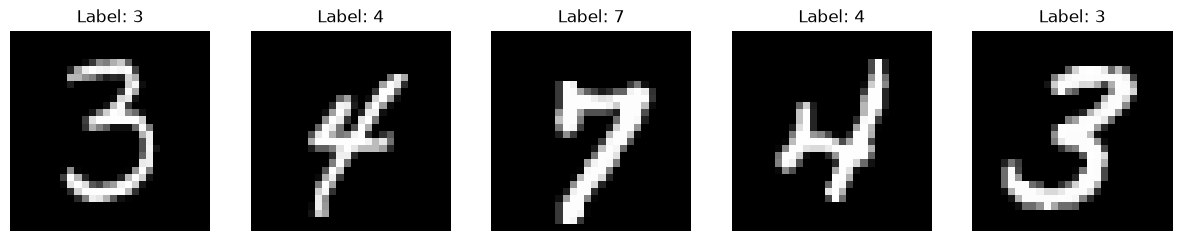

In [4]:
# Cell 3.5: Visualize
import matplotlib.pyplot as plt

# Display 5 random images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
indices = np.random.choice(len(train_images), 5, replace=False)

for idx, ax in enumerate(axes):
    # Reshape back to 28x28 for plotting
    ax.imshow(train_images[indices[idx]].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {np.argmax(train_labels[indices[idx]])}")
    ax.axis('off')
plt.show()

In [5]:
# Cell 4: Training Loop
model = MNIST_CNN()
model.train()
criterion = CrossEntropyLoss()
optimizer = SGD(layers=[model.conv1, model.fc1], lr=0.01)

num_samples = len(train_images)
epochs = 5

for epoch in range(epochs):
    epoch_loss = 0
    correct = 0
    
    for i in range(num_samples):
        # 1. Forward Pass
        prediction = model(train_images[i])
        
        # 2. Loss Calculation
        loss = criterion.forward(prediction, train_labels[i])
        epoch_loss += loss
        
        # Check accuracy
        if np.argmax(prediction) == np.argmax(train_labels[i]):
            correct += 1
            
        # 3. Backward Pass
        d_out = criterion.backward()
        d_out = model.fc1.backward(d_out)
        d_out = model.flatten.backward(d_out)
        d_out = model.pool1.backward(d_out)
        d_out = model.relu1.backward(d_out)
        d_out = model.conv1.backward(d_out)
        
        # 4. Update Weights
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch+1} | Loss: {epoch_loss/num_samples:.4f} | Accuracy: {(correct/num_samples)*100:.2f}%")

print("Training Complete!")

Epoch 1 | Loss: 2.2764 | Accuracy: 16.80%
Epoch 2 | Loss: 0.9249 | Accuracy: 70.60%
Epoch 3 | Loss: 0.4943 | Accuracy: 84.60%
Epoch 4 | Loss: 0.3644 | Accuracy: 88.00%
Epoch 5 | Loss: 0.2697 | Accuracy: 90.40%
Training Complete!



--- Running Evaluation on Test Set ---

--- High-Confidence Errors ---


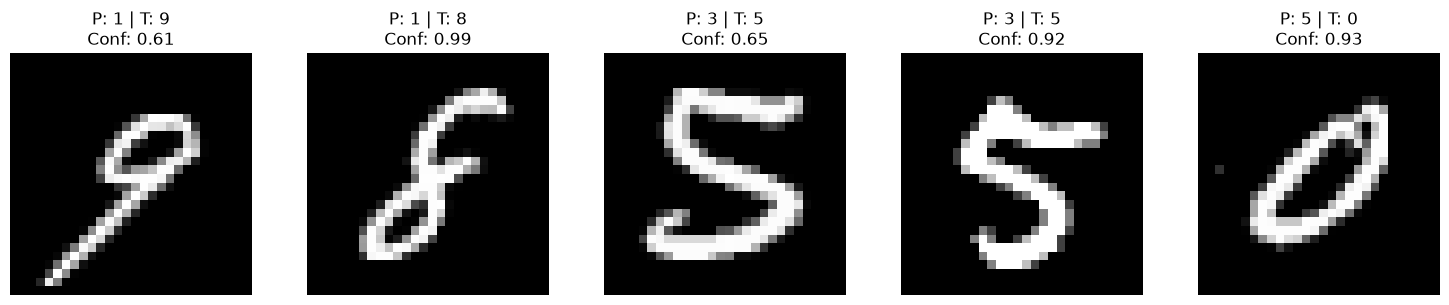


--- High-Confidence Corrects ---


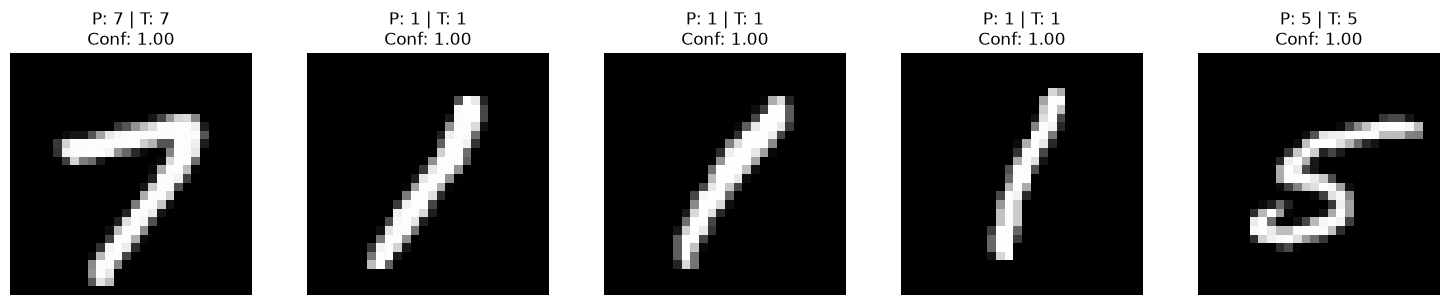

In [6]:
model.eval()
wrong_predictions = []
correct_predictions = []

print("\n--- Running Evaluation on Test Set ---")
for i in range(len(test_images)):
    # 1. Forward Pass (No backward/training needed)
    prediction = model(test_images[i])
    
    # 2. Extract results
    pred_idx = np.argmax(prediction)
    true_idx = np.argmax(test_labels[i])
    confidence = np.max(prediction)
    
    # 3. Categorize results based on confidence
    # Error: Wrong prediction with high certainty
    if pred_idx != true_idx and confidence > 0.5:
        wrong_predictions.append((i, pred_idx, true_idx, confidence))
    
    # Correct: Right prediction with high certainty
    elif pred_idx == true_idx and confidence > 0.9:
        correct_predictions.append((i, pred_idx, true_idx, confidence))

# --- Displaying Results ---
def show_results(data_list, title):
    if len(data_list) == 0:
        print(f"No {title} found.")
        return
        
    print(f"\n--- {title} ---")
    plt.figure(figsize=(15, 3))
    for i, (idx, pred, actual, conf) in enumerate(data_list[:5]):
        plt.subplot(1, 5, i + 1)
        # Reshape to (28, 28) to ensure proper visualization
        plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f"P: {pred} | T: {actual}\nConf: {conf:.2f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_results(wrong_predictions, "High-Confidence Errors")
show_results(correct_predictions, "High-Confidence Corrects")

# Set back to training mode
for layer in [model.conv1, model.relu1, model.pool1, model.flatten, model.fc1]:
    layer.train()